In [1]:
%cd ..

/home/ricka/Git/GitHub/RickArko/kaggle/comp/kcom-predicting-stellar-class


# Modeling — Predicting Stellar Class (S6E6)

**Strategy:**  
Train three gradient-boosted classifiers (LightGBM, XGBoost, CatBoost) with stratified
5-fold cross-validation, then stack their out-of-fold probability predictions with a
Logistic Regression meta-model.

### Contents
1. Load & engineer features
2. Cross-validation training (base models)
3. Stacking (meta-model)
4. Generate submission

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from stellar.data import load_data
from stellar.features import make_features
from stellar.models import train_cv, save_submission

train, test = load_data('data/')
X_train, X_test, y_train = make_features(train, test)

print('X_train:', X_train.shape)
print('X_test: ', X_test.shape)

X_train: (577347, 12)
X_test:  (247435, 12)


## 1. Cross-Validation Training & Stacking

In [3]:
oof_meta, test_preds = train_cv(
    X_train, y_train, X_test,
    n_splits=5,
    random_state=42
)

/home/ricka/Git/GitHub/RickArko/kaggle/comp/kcom-predicting-stellar-class/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
CV fold: 100%|██████████| 5/5 [08:20<00:00, 100.16s/fold]


## 2. Submission Preview

In [4]:
print('Prediction distribution:')
print(pd.Series(test_preds).value_counts())

Prediction distribution:
GALAXY    162177
QSO        50002
STAR       35256
Name: count, dtype: int64


## 3. Save Submission

In [5]:
save_submission(
    test_ids=test['id'],
    predictions=test_preds,
    output_path='../outputs/submissions/submission.csv'
)

## 4. OOF Confusion Matrix

OOF Balanced Accuracy: 0.9525


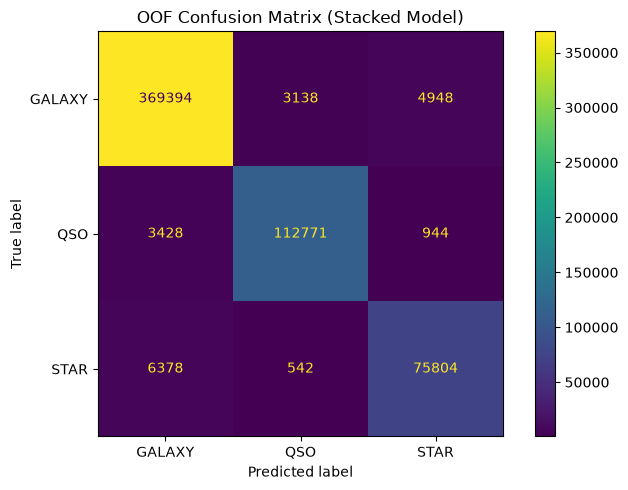

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import ConfusionMatrixDisplay, balanced_accuracy_score

le = LabelEncoder()
y_enc = le.fit_transform(y_train)

meta = LogisticRegression(max_iter=1000, random_state=42)
meta.fit(oof_meta, y_enc)
oof_preds = meta.predict(oof_meta)

print(f'OOF Balanced Accuracy: {balanced_accuracy_score(y_enc, oof_preds):.4f}')

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    le.inverse_transform(y_enc),
    le.inverse_transform(oof_preds),
    display_labels=le.classes_,
    ax=ax
)
ax.set_title('OOF Confusion Matrix (Stacked Model)')
plt.tight_layout()
plt.show()